# 03 — Models

Three models on the same folds: a logistic regression as the white box, XGBoost as the machine
learning model, and TabPFN as the tabular foundation model. TabPFN runs on a GPU in Colab, so it has
its own notebook (`03b_tabpfn_colab.ipynb`) and comes back as a file.

The point of this notebook is not the scores, it is the **out-of-fold predictions**: every pair gets
a prediction from a model that never saw it during training. Notebooks 04 to 06 read those
predictions instead of refitting anything, so interpretability, stability and fairness can be worked
on in parallel.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from pathlib import Path

if not Path("data").is_dir():
    os.chdir("..")   # works whether Jupyter started at the repo root or inside notebooks/

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

table = pd.read_csv("data/processed/model_table.csv")

CATEGORICAL = ["her_field", "her_race", "her_goal", "his_field", "his_race", "his_goal"]
X = table.drop(columns=["pair", "wave", "match", "fold"])
y = table.match
groups = table.wave

print(X.shape[1], "columns,", len(X), "pairs,", round(y.mean(), 3), "positive")

58 columns, 4184 pairs, 0.165 positive


## 1. The folds

Notebook 02 already assigned every pair to a fold and stored it in the table, so every model here is
scored on the same split — and so is TabPFN, which reads the same file in Colab.

In [2]:
cv = StratifiedGroupKFold(5, shuffle=True, random_state=0)   # the one 02 used, kept for reference

table.groupby("fold").agg(pairs=("match", "size"), matches=("match", "sum"),
                          rate=("match", "mean"), waves=("wave", "nunique")).round(3)

,pairs,matches,rate,waves
fold,,,,
0,847,137,0.162,4
1,877,140,0.160,4
2,827,122,0.148,4
3,823,133,0.162,5
4,810,158,0.195,4


## 2. The white box: logistic regression

The brief asks for a white-box model and the obvious one is a logistic regression: one coefficient
per feature, readable signs, and a prediction any analyst can reproduce by hand.

The only real choice is the penalty. All of them score the same here, so we pick on sparsity rather
than on decimals.

In [3]:
def encoded(final_step):
    """One-hot the six category codes on the training fold only, then impute, scale, and fit."""
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), CATEGORICAL)],
        remainder="passthrough")
    return make_pipeline(encode, SimpleImputer(strategy="median"), StandardScaler(), final_step)

penalties = {
    "ridge (L2), C=1":   LogisticRegression(max_iter=3000, C=1),
    "lasso (L1), C=0.1":  LogisticRegression(max_iter=3000, C=0.1, l1_ratio=1, solver="liblinear"),
    "lasso (L1), C=0.05": LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1, solver="liblinear"),
}

rows = []
for name, est in penalties.items():
    pipe = encoded(est)
    auc = cross_val_score(pipe, X, y, cv=cv, groups=groups, scoring="roc_auc")
    pipe.fit(X, y)
    rows.append({"penalty": name, "ROC-AUC": round(auc.mean(), 3),
                 "features kept": int((pipe[-1].coef_ != 0).sum())})

pd.DataFrame(rows).set_index("penalty")

,ROC-AUC,features kept
penalty,,
"ridge (L2), C=1",0.581,97
"lasso (L1), C=0.1",0.576,60
"lasso (L1), C=0.05",0.574,48


The lasso at `C=0.05` drops half the features for three thousandths of AUC, which is well inside the
fold-to-fold noise. Half as many coefficients to put in front of the client is worth far more than
that, so this is our white box.

48 features kept out of 97


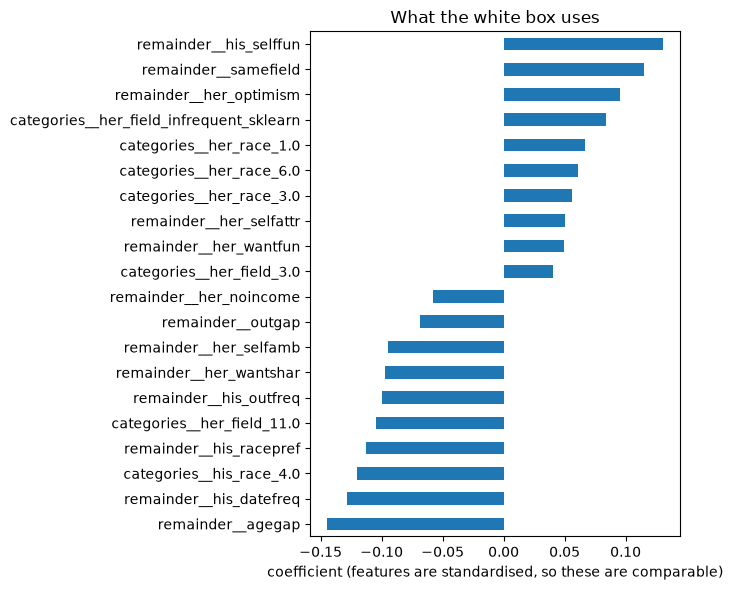

In [4]:
white_box = encoded(LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1, solver="liblinear"))
white_box.fit(X, y)

names = white_box[0].get_feature_names_out()
coefs = pd.Series(white_box[-1].coef_.ravel(), index=names)
coefs = coefs[coefs != 0].sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
pd.concat([coefs.head(10), coefs.tail(10)]).plot.barh(ax=ax)
ax.set_xlabel("coefficient (features are standardised, so these are comparable)")
ax.set_title("What the white box uses")
plt.tight_layout()

print(len(coefs), "features kept out of", len(names))

## 3. XGBoost

Same pipeline, without the scaling it does not need. The settings are deliberately modest: 4,184 rows
with a 16.5% positive rate is not much, and a deeper model only memorises the training waves.

In [5]:
def boosted():
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), CATEGORICAL)],
        remainder="passthrough")
    return make_pipeline(encode, SimpleImputer(strategy="median"),
                         XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                       subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                                       random_state=0))

## 4. Out-of-fold predictions

One pass over the folds. Each model is fitted on four folds and predicts the fifth, so every pair
ends up with a prediction from a model that never saw it.

In [6]:
MODELS = {"logit": lambda: encoded(LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1,
                                                      solver="liblinear")),
          "xgboost": boosted}

oof = table[["pair", "wave", "fold", "match"]].copy()
for name in MODELS:
    oof[name] = np.nan

for k in sorted(table.fold.unique()):
    train, test = table.fold != k, table.fold == k
    for name, build in MODELS.items():
        model = build().fit(X[train], y[train])
        oof.loc[test, name] = model.predict_proba(X[test])[:, 1]

print("predictions missing:", oof[list(MODELS)].isna().sum().sum())
oof.head(3)

predictions missing: 0


,pair,wave,fold,match,logit,xgboost
0,"(1, 11)",1,1,0,0.108784,0.044300
1,"(1, 12)",1,1,0,0.347853,0.154112
2,"(1, 13)",1,1,1,0.156381,0.124018


In [7]:
oof.to_csv("data/processed/oof_predictions.csv", index=False)
print("saved", oof.shape, "to data/processed/oof_predictions.csv")

saved (4184, 6) to data/processed/oof_predictions.csv


## 5. Where we stand

Two numbers per model. ROC-AUC says how well the pairs are ranked overall; PR-AUC is the one to watch
here, because only 16.5% of pairs match and a model can look respectable on ROC-AUC while being
useless at the top of the ranking, which is the only part the app would ever show.

In [8]:
def score(column):
    per_fold = [roc_auc_score(g.match, g[column]) for _, g in oof.groupby("fold")]
    return {"ROC-AUC": round(roc_auc_score(oof.match, oof[column]), 3),
            "PR-AUC": round(average_precision_score(oof.match, oof[column]), 3),
            "worst fold": round(min(per_fold), 3),
            "best fold": round(max(per_fold), 3)}

results = pd.DataFrame({name: score(name) for name in MODELS}).T
results.index.name = "model"
results

,ROC-AUC,PR-AUC,worst fold,best fold
model,,,,
logit,0.570,0.201,0.528,0.633
xgboost,0.591,0.207,0.545,0.625


In [9]:
# What the client would actually see: if the app shows the top 10% of pairs, how many are matches?
base = oof.match.mean()
rows = []
for name in MODELS:
    top = oof.nlargest(int(0.10 * len(oof)), name)
    rows.append({"model": name, "match rate in the top 10%": round(top.match.mean(), 3),
                 "lift over showing pairs at random": round(top.match.mean() / base, 2)})

pd.DataFrame(rows).set_index("model")

,match rate in the top 10%,lift over showing pairs at random
model,,
logit,0.23,1.39
xgboost,0.22,1.33


## 6. TabPFN

TabPFN needs a GPU to be practical, so it runs in `03b_tabpfn_colab.ipynb` on Colab. The recipe:

1. open `03b` in Colab and switch the runtime to a GPU;
2. upload `data/processed/model_table.csv` when it asks;
3. it fits TabPFN on the same five folds and offers `tabpfn_oof.csv` for download;
4. drop that file in `data/processed/` and run the cell below to merge it in.

The fold column travels with the data, so TabPFN is scored on exactly the same split as the two
models above.

In [10]:
from pathlib import Path

tabpfn_file = Path("data/processed/tabpfn_oof.csv")
if tabpfn_file.exists():
    oof["tabpfn"] = pd.read_csv(tabpfn_file).set_index("pair").tabpfn.reindex(oof.pair).to_numpy()
    oof.to_csv("data/processed/oof_predictions.csv", index=False)
    print(pd.DataFrame({n: score(n) for n in list(MODELS) + ["tabpfn"]}).T)
else:
    print("tabpfn_oof.csv not here yet — run 03b in Colab, then re-run this cell.")

tabpfn_oof.csv not here yet — run 03b in Colab, then re-run this cell.


## What the next notebooks get

`data/processed/oof_predictions.csv`: one row per pair with `wave`, `fold`, `match` and one
probability column per model, all out-of-fold.

- **04, interpretability**: coefficients and odds ratios for the logit, SHAP for XGBoost.
- **05, stability**: the fold-to-fold spread, and the deliberate stress test — train on the
  large-group waves, test on the small-group ones.
- **06, fairness**: the metrics by ethnicity and for mixed against same-ethnicity pairs, then the
  experiment that matters — refit without `race` and see whether `imprace` and the income columns put
  the gap back on their own.

Still missing: the cost matrix. Without it there is no economic performance, and the brief asks for
it. What a match is worth against what a wasted recommendation costs is a decision for the team, not
something to invent here.